# Dimensionality Reduction

## Why Reduce Dimensions?
1. **Curse of dimensionality**: data becomes sparse in high dimensions
2. **Visualization**: reduce to 2D/3D for plotting
3. **Noise removal**: keep meaningful variance
4. **Compression**: reduce storage and compute
5. **Feature extraction**: create better features

**Feature Selection vs Feature Extraction**:
- Selection: choose a subset of original features
- Extraction: create new features (linear/non-linear combinations)

---

## 1. Principal Component Analysis (PCA)

Find orthogonal directions of **maximum variance**.

### Derivation:

1. Center data: $\tilde{X} = X - \bar{X}$

2. Covariance matrix: $C = \frac{1}{n-1}\tilde{X}^T\tilde{X}$

3. Eigen decomposition: $C = V \Lambda V^T$

4. First principal component: $w_1 = \arg\max_{\|w\|=1} w^T C w = v_1$ (eigenvector with largest eigenvalue)

5. Project: $Z = \tilde{X} V_k$ where $V_k$ contains top-$k$ eigenvectors

**Alternatively via SVD**: $\tilde{X} = U \Sigma V^T$

The principal components are the right singular vectors $V$.

**Explained Variance Ratio**: 
$$\text{EVR}_j = \frac{\lambda_j}{\sum_i \lambda_i}$$

Choose $k$ such that cumulative EVR $\geq 0.95$.

### Reconstruction Error:
$$\text{Error} = \|X - X_{reconstructed}\|_F^2 = \sum_{i=k+1}^{d} \lambda_i$$

---

## 2. Kernel PCA

For non-linear structure. Apply kernel $K(x_i, x_j)$ to map to feature space, then PCA:

$$[K]_{ij} = K(x_i, x_j) = \phi(x_i)^T \phi(x_j)$$

Center: $\tilde{K} = K - \mathbf{1}_n K - K \mathbf{1}_n + \mathbf{1}_n K \mathbf{1}_n$

Eigen decompose $\tilde{K}$ for projections.

---

## 3. t-SNE (t-Distributed Stochastic Neighbor Embedding)

Non-linear, primarily for visualization.

### High-dimensional similarities:
$$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k\neq i}\exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}, \quad p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$$

### Low-dimensional similarities (t-distribution, 1 dof):
$$q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k\neq l}(1 + \|y_k - y_l\|^2)^{-1}}$$

The t-distribution has heavier tails → separates clusters better.

### Objective minimize KL divergence:
$$C = KL(P\|Q) = \sum_{ij} p_{ij}\log\frac{p_{ij}}{q_{ij}}$$

Optimized by gradient descent.

**Perplexity**: hyperparameter controlling effective number of neighbors (typically 5-50).

---

## 4. UMAP (Uniform Manifold Approximation and Projection)

Based on **Riemannian geometry** and **algebraic topology**.

Key idea: Construct a fuzzy topological representation of the high-dimensional data, then optimize a low-dimensional embedding to have the same fuzzy topological structure.

1. Build a weighted $k$-NN graph in high dimensions with weights:
$$w(x_i, x_j) = \exp\left(-\frac{d(x_i, x_j) - \rho_i}{\sigma_i}\right)$$

2. Convert to symmetric: $\bar{w}(x_i, x_j) = w_{ij} + w_{ji} - w_{ij}w_{ji}$

3. Optimize low-dimensional coordinates by minimizing cross-entropy between high and low-dimensional fuzzy sets.

**UMAP vs t-SNE**: UMAP is faster, preserves global structure better, can be used for new points.

---

## 5. Linear Discriminant Analysis (LDA)

**Supervised** dimensionality reduction maximize class separability:

$$J(w) = \frac{w^T S_B w}{w^T S_W w}$$

Where:
- $S_B = \sum_c n_c(\mu_c - \mu)(\mu_c - \mu)^T$ (between-class scatter)
- $S_W = \sum_c \sum_{x \in C_c}(x - \mu_c)(x - \mu_c)^T$ (within-class scatter)

Solution: generalized eigenvectors of $S_W^{-1} S_B$.

Max components: $\min(n_{classes}-1, n_{features})$

---

## 6. ICA (Independent Component Analysis)

Find statistically **independent** components (not just uncorrelated like PCA):

$$x = As \Rightarrow s = Wx$$

Maximize non-Gaussianity (kurtosis or negentropy) of components.

**FastICA**: uses Newton's method on negentropy approximation.

Application: blind source separation (cocktail party problem).

---

## 7. Autoencoders for Dimensionality Reduction

Neural network that learns to compress:

$$z = \text{Encoder}(x), \quad \hat{x} = \text{Decoder}(z)$$

Minimize reconstruction loss: $\mathcal{L} = \|x - \hat{x}\|^2$

Linear autoencoder with identity activations = PCA.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, make_circles
from sklearn.decomposition import PCA, KernelPCA, FastICA, TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
np.random.seed(42)

X_digits, y_digits = load_digits(return_X_y=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_digits)

## PCA from Scratch

In [2]:
class PCAScratch:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components_ = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_
        # Covariance matrix
        C = X_centered.T @ X_centered / (X.shape[0] - 1)
        # Eigendecomposition
        eigenvalues, eigenvectors = np.linalg.eigh(C)
        # Sort descending
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]
        self.components_ = eigenvectors[:, :self.n_components].T
        self.explained_variance_ratio_ = eigenvalues[:self.n_components] / eigenvalues.sum()
        return self

    def transform(self, X):
        return (X - self.mean_) @ self.components_.T

    def inverse_transform(self, Z):
        return Z @ self.components_ + self.mean_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


pca_scratch = PCAScratch(n_components=2)
X_2d_scratch = pca_scratch.fit_transform(X_scaled)
print(f'Scratch PCA explained variance: {pca_scratch.explained_variance_ratio_.sum():.4f}')

Scratch PCA explained variance: 0.2159


## PCA Scree Plot & Visualization

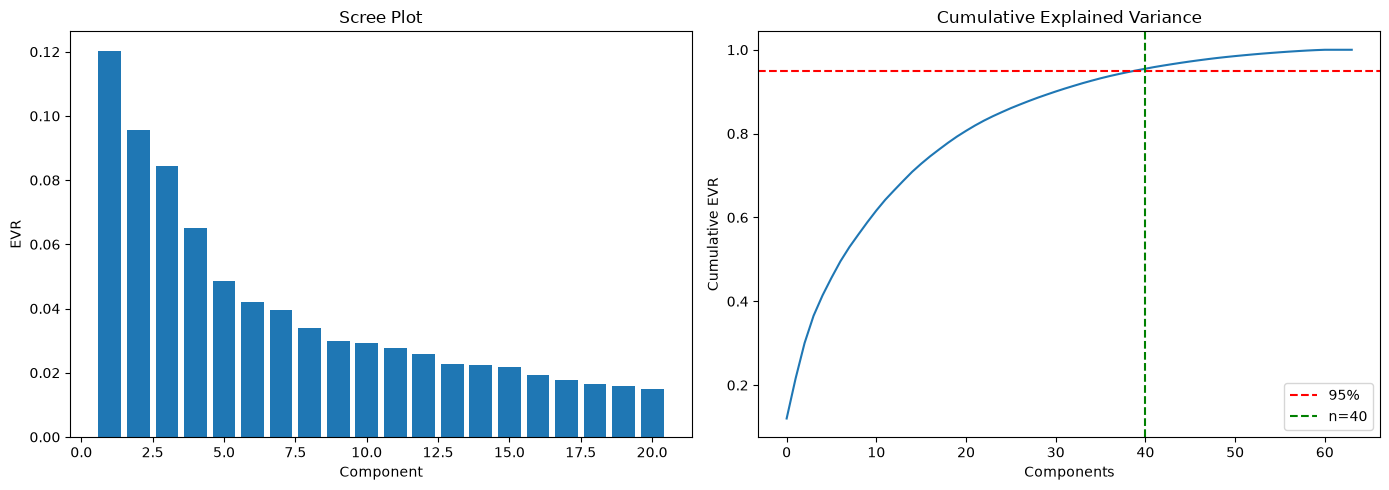

Components for 95% variance: 40


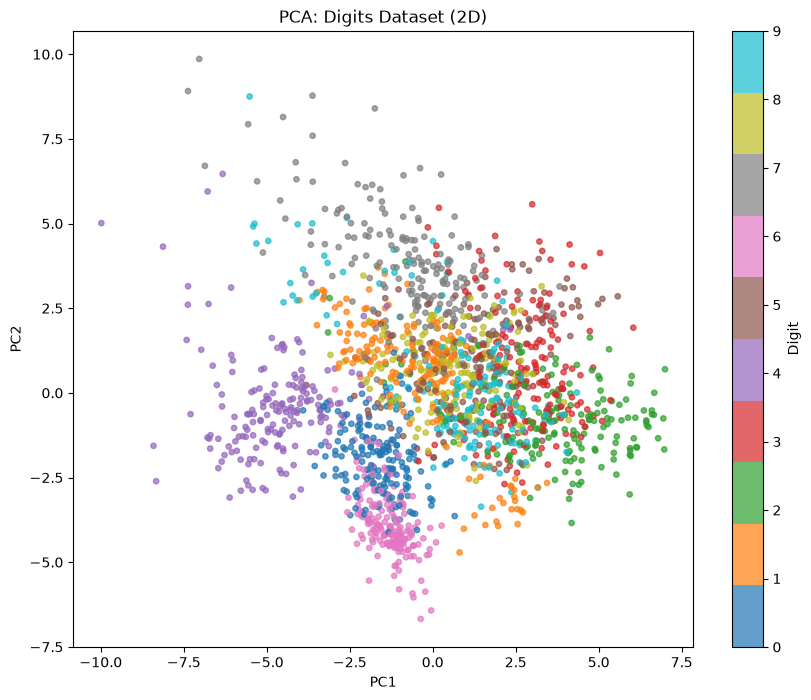

In [3]:
pca_full = PCA().fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

n_95 = np.searchsorted(cumvar, 0.95) + 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20])
axes[0].set_xlabel('Component'); axes[0].set_ylabel('EVR'); axes[0].set_title('Scree Plot')
axes[1].plot(cumvar)
axes[1].axhline(0.95, color='r', linestyle='--', label='95%')
axes[1].axvline(n_95, color='g', linestyle='--', label=f'n={n_95}')
axes[1].set_xlabel('Components'); axes[1].set_ylabel('Cumulative EVR')
axes[1].set_title('Cumulative Explained Variance'); axes[1].legend()
plt.tight_layout(); plt.show()
print(f'Components for 95% variance: {n_95}')

# 2D visualization
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_digits, cmap='tab10', s=15, alpha=0.7)
plt.colorbar(scatter, label='Digit')
plt.title('PCA: Digits Dataset (2D)')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.show()

## t-SNE vs UMAP vs PCA Comparison')

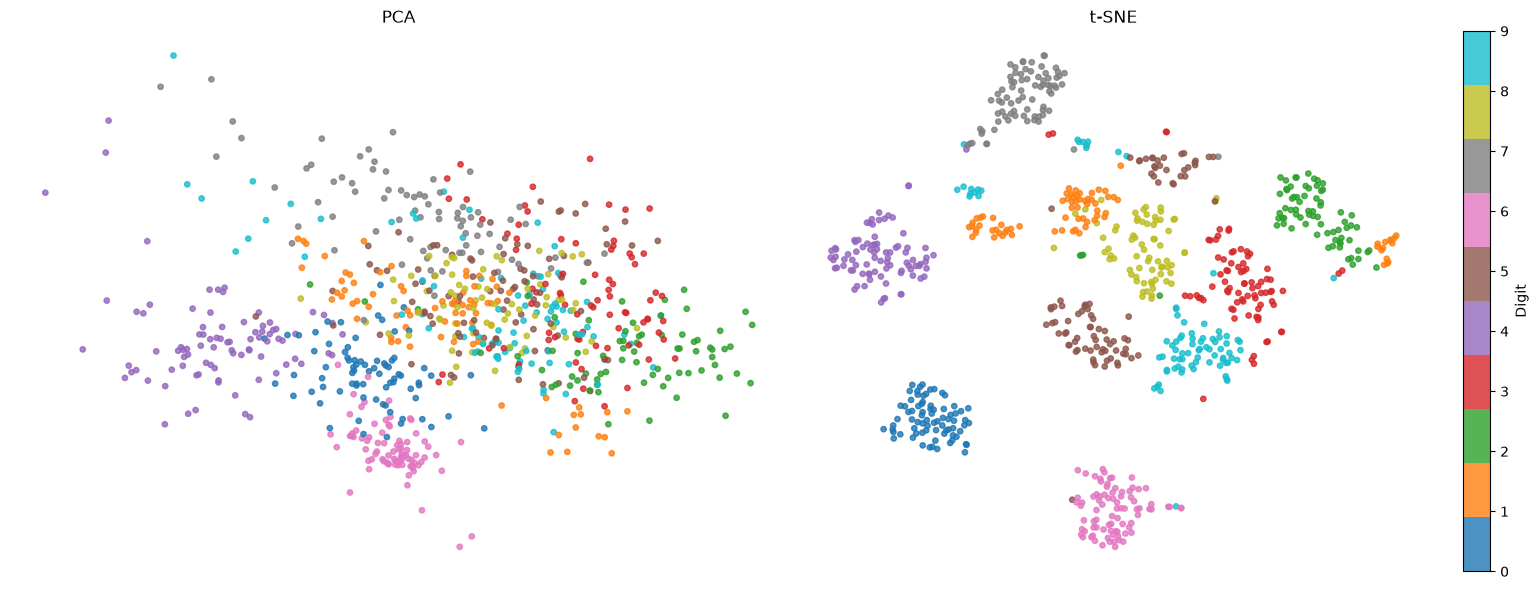

In [4]:
# Use subset for speed
idx = np.random.choice(len(X_scaled), 800, replace=False)
X_sub, y_sub = X_scaled[idx], y_digits[idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_sub)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
X_pca_sub = PCA(n_components=2).fit_transform(X_sub)
for ax, X_emb, title in zip(axes, [X_pca_sub, X_tsne], ['PCA', 't-SNE']):
    sc = ax.scatter(X_emb[:, 0], X_emb[:, 1], c=y_sub, cmap='tab10', s=15, alpha=0.8)
    ax.set_title(title); ax.axis('off')
plt.colorbar(sc, ax=axes[-1], label='Digit')
plt.tight_layout(); plt.show()

## LDA Supervised Dimensionality Reduction')

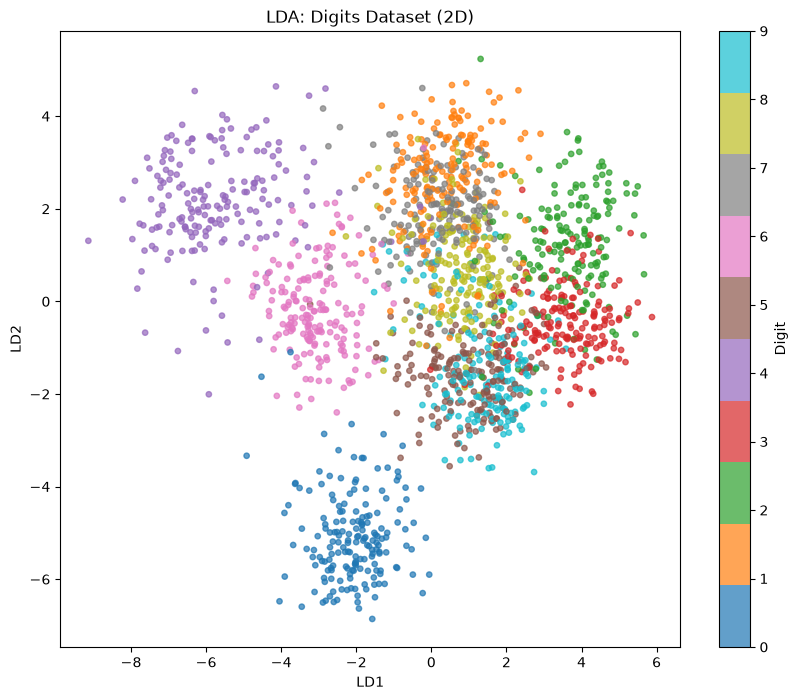

In [5]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y_digits)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y_digits, cmap='tab10', s=15, alpha=0.7)
plt.colorbar(scatter, label='Digit')
plt.title('LDA: Digits Dataset (2D)')
plt.xlabel('LD1'); plt.ylabel('LD2'); plt.show()

## Kernel PCA for Non-Linear Data')

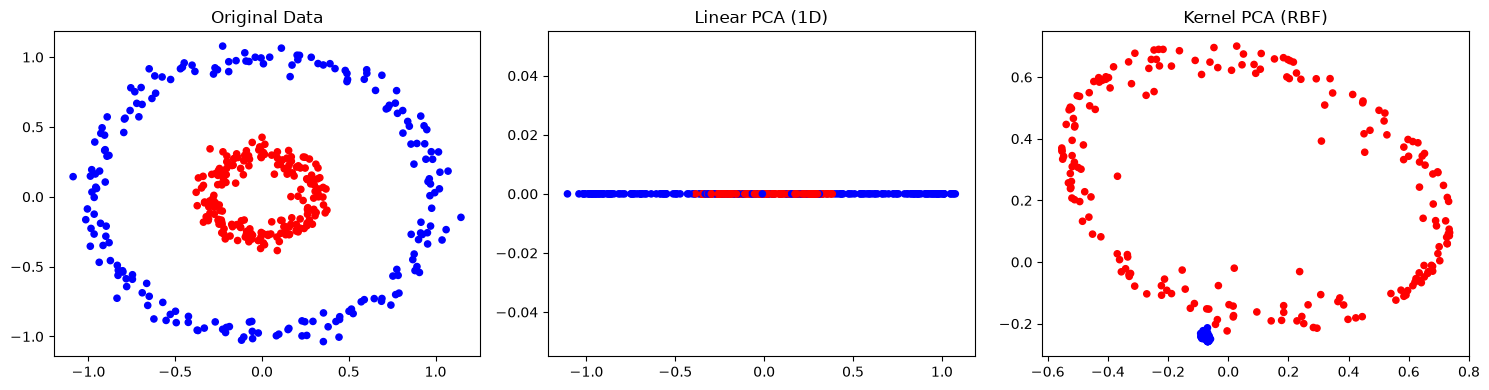

In [6]:
X_c, y_c = make_circles(n_samples=400, noise=0.05, factor=0.3, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original
axes[0].scatter(X_c[:, 0], X_c[:, 1], c=y_c, cmap='bwr', s=20)
axes[0].set_title('Original Data')

# Linear PCA
pca_lin = PCA(n_components=1).fit_transform(X_c)
axes[1].scatter(pca_lin, np.zeros_like(pca_lin), c=y_c, cmap='bwr', s=20)
axes[1].set_title('Linear PCA (1D)')

# Kernel PCA (RBF)
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=10)
X_kpca = kpca.fit_transform(X_c)
axes[2].scatter(X_kpca[:, 0], X_kpca[:, 1], c=y_c, cmap='bwr', s=20)
axes[2].set_title('Kernel PCA (RBF)')

plt.tight_layout(); plt.show()

## Additional Learning Resources

### Papers
- 📄 [t-SNE: Visualizing Data using t-SNE (Van der Maaten & Hinton 2008)](https://jmlr.org/papers/v9/vandermaaten08a.html)
- 📄 [UMAP: Uniform Manifold Approximation and Projection (McInnes et al. 2018)](https://arxiv.org/abs/1802.03426)
- 📄 [PCA Jolliffe (2002)](https://link.springer.com/book/10.1007/b98835)
- 📄 [FastICA Algorithm (Hyvärinen & Oja 2000)](https://www.cs.helsinki.fi/u/ahyvarin/papers/NN00new.pdf)

### Videos
- 🎥 [StatQuest: PCA](https://www.youtube.com/watch?v=FgakZw6K1QQ)
- 🎥 [StatQuest: t-SNE](https://www.youtube.com/watch?v=NEaUSP4YerM)
- 🎥 [StatQuest: UMAP](https://www.youtube.com/watch?v=eN0wFzBA4Sc)
- 🎥 [StatQuest: LDA](https://www.youtube.com/watch?v=azXCzI57Yfc)

### Documentation
- 📚 [Scikit-Learn Decomposition](https://scikit-learn.org/stable/modules/decomposition.html)
- 📚 [UMAP Documentation](https://umap-learn.readthedocs.io/)

### Interactive
- 🌐 [How to Use t-SNE Effectively](https://distill.pub/2016/misread-tsne/) Distill.pub